# Discrete Multi-Exponential Lifetime Fitting

This notebook demonstrates `LifetimeFitter` — fitting a PALS spectrum with a discrete number of lifetime components:

$$N(t) = \mathrm{IRF}(t) \otimes \sum_i \frac{I_i}{\tau_i} e^{-(t-t_0)/\tau_i}\,\Theta(t-t_0) + \mathrm{bg}$$

Every parameter ($\tau_i$, $I_i$, $t_0$, background) is a `FitParameter` that can be **free** (with optional bounds) or **fixed**. Intensities are constrained to sum to 1 — the last non-fixed intensity is computed as $1 - \sum(\text{others})$, the PALSfit convention. Fixing parameters is also how **source corrections** are applied: fix the source component's $\tau$ and $I$ to their known values.

Errors come from the least-squares Jacobian at the optimum, scaled by the reduced $\chi^2$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

from scipas.core.time_resolution import MultiGaussianRF
from scipas.core.lifetime import PASLifetime
from scipas.model.lifetime import LifetimeModel
from scipas.analysis.lifetime import (
    generate_random_lt_spectrum,
    LifetimeFitter,
    FitParameter,
)
from scipas.analysis.lifetime.fit.intensities import solve_intensities, _convolved_decay
from scispectrum import Spectrum

np.random.seed(42)

## 1. Synthetic two-component spectrum

Ground truth: $\tau_1 = 0.22$ ns (75%) and $\tau_2 = 1.80$ ns (25%), $t_0 = 0.05$ ns, flat background of 20 counts/bin, $2\times 10^6$ events. IRF: Gaussian, FWHM 230 ps.

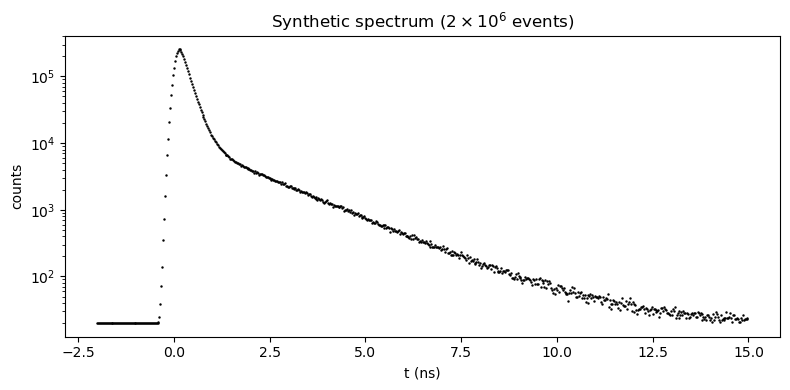

In [2]:
time = np.arange(-2, 15, 0.025)                     # ns
irf_sigma = np.array([0.230 / (2 * np.sqrt(2 * np.log(2)))])
irf = MultiGaussianRF(irf_sigma, np.ones_like(irf_sigma), np.zeros_like(irf_sigma))

true_taus = [0.125, 0.22, 1.80]
true_I = [(1/3)*0.25, 0.75, (2/3)*0.25]
true_t0 = 0.05
bg_true = 20.0

# Inject a genuine time-zero offset by centering the *generating* IRF at true_t0.
# The fit is given the centered `irf`, so its free t0 parameter must absorb the
# shift. (Subtracting true_t0 from the time axis would not do this — it just
# relabels the axis, leaving t0 = 0 on the spectrum's own grid.)
irf_shifted = MultiGaussianRF(irf_sigma, np.ones_like(irf_sigma), np.array([true_t0]))
truth_model = LifetimeModel("truth", lifetimes=np.array(true_taus), intensities=true_I)
r = generate_random_lt_spectrum(time, truth_model, irf_shifted, num_events=5_000_000)
pals = PASLifetime(
    lifetime=Spectrum(counts=r.lifetime.counts + bg_true, axis_calib=r.lifetime.axis_calib),
    resolution=irf,
)

plt.figure(figsize=(8, 4))
plt.semilogy(time, pals.lifetime.counts, 'k.', ms=1.5)
plt.xlabel('t (ns)'); plt.ylabel('counts')
plt.title('Synthetic spectrum ($2\\times 10^6$ events)')
plt.tight_layout()

## 2. Fit with all parameters free

Initial guesses deliberately off; $t_0$ and background are free as well.

In [3]:
fitter = LifetimeFitter()

In [4]:
lifetime_components=[
    FitParameter(value=0.1, lower=0.01, upper=0.3, fixed=False),
    FitParameter(value=0.25, lower=0.01, upper=1.0, fixed=False),
    FitParameter(value=1.2, lower=0.01, upper=10.0)]
t0=FitParameter(0.0, lower=-1, upper=1)
background=FitParameter(10.0, lower=0.0, upper=100)

In [5]:
results = fitter.fit(pals=pals, background=background, lifetime_components=lifetime_components, t0=t0)

In [6]:
fit_τ, fit_I, fit_t0, fit_bg = results.opt_parameters()
fit_τ, fit_I, fit_t0, fit_bg 

(array([0.13161766, 0.2211838 , 1.79011909]),
 array([0.09986936, 0.73344127, 0.16663166]),
 0.04998587067500991,
 20.220345133358574)

In [7]:
pals_fit = results.generate(lifetimes=fit_τ, intensities=fit_I, t0=fit_t0, background=fit_bg)

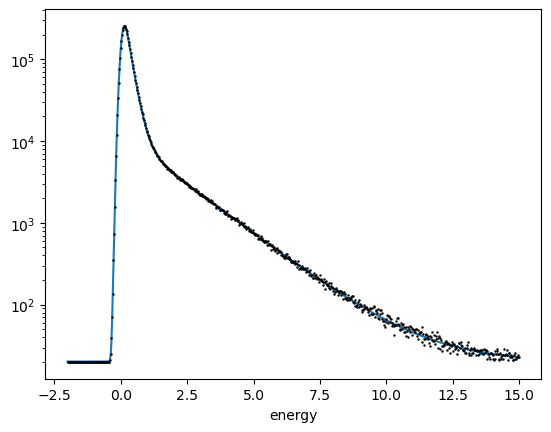

In [8]:
pals_fit.lifetime.plot()
plt.semilogy(time, pals.lifetime.counts, 'k.', ms=1.5)

Error around fit

In [9]:
num_of_sample = 1000
sample_τ, sample_I, sample_t0, sample_bg = results.sample(size=num_of_sample, rng=1)
sample_fit = np.zeros((num_of_sample, len(pals.lifetime.channels)))
for i in range(num_of_sample):
    sample_fit[i,:] = results.generate(lifetimes=sample_τ[i], intensities=sample_I[i], t0=sample_t0[i], background=sample_bg[i]).lifetime.counts

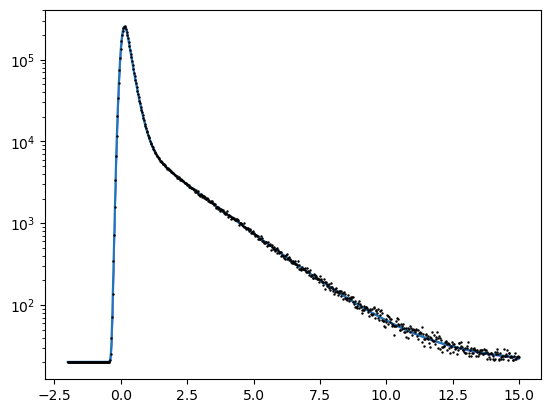

In [10]:
plt.semilogy(time, sample_fit.mean(axis=0))
plt.fill_between(time, y1=sample_fit.mean(axis=0)+sample_fit.std(axis=0),
                 y2=sample_fit.mean(axis=0)-sample_fit.std(axis=0), alpha=0.5, color="blue")

plt.semilogy(time, pals.lifetime.counts, 'k.', ms=1.5)


In [11]:
sample_I.std(axis=0)/sample_I.mean(axis=0)*100

array([37.26872809,  5.39191087,  0.2809271 ])

In [12]:
# Create a 4x4 array
grid = np.array([
    [10, 11, 12, 13],
    [20, 21, 22, 23],
    [30, 31, 32, 33],
    [40, 41, 42, 43]
])

# We want rows 0 and 2, combined with columns 1 and 3
rows = [0, 2]
cols = [1, 3]

# Extract the sub-grid using np.ix_
result = grid[np.ix_(rows, cols)]
print(np.ix_(rows, cols))

(array([[0],
       [2]]), array([[1, 3]]))


In [13]:
grid[np.ix_(rows, cols)]

array([[11, 13],
       [31, 33]])

In [14]:
grid[[[0], [2]], [[1, 3]]]

array([[11, 13],
       [31, 33]])

In [15]:
sample_τ.mean(axis=0) #+ sample_τ.std(axis=0)

array([0.13159776, 0.2211957 , 1.79036834])

In [16]:
sample_τ.std(axis=0)

array([0.0149723 , 0.00280716, 0.00391993])